In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter

In [2]:
# ENVIRONMENT
# ==============================

bounds = np.array([
    [0, 50],  # x
    [0, 50],  # y
    [0, 20]   # z
])

np.random.seed(42)
N_OBS = 6
obstacles = [
    (
        np.random.uniform(bounds[0,0], bounds[0,1]),
        np.random.uniform(bounds[1,0], bounds[1,1]),
        np.random.uniform(3, 6)
    )
    for _ in range(N_OBS)
]

In [3]:
# ==============================
# TARGET FORMATION
# ==============================

def circle_formation(N, radius=10):
    angles = np.linspace(0, 2*np.pi, N, endpoint=False)
    x = 25 + radius * np.cos(angles)
    y = 25 + radius * np.sin(angles)
    z = np.full(N, 10)
    return np.vstack([x, y, z]).T

N_DRONES = 8
target_positions = circle_formation(N_DRONES)

In [4]:
# ==============================
# FITNESS
# ==============================

def obstacle_penalty(positions):
    pen = 0
    for ox, oy, r in obstacles:
        d = np.sqrt((positions[:,0]-ox)**2 + (positions[:,1]-oy)**2)
        overlap = np.maximum(0, r - d)
        pen += np.sum(overlap)
    return pen

def fitness(positions, safe_dist=2.0):
    N = len(positions)

    from scipy.optimize import linear_sum_assignment

    cost_matrix = np.linalg.norm(
        positions[:, None, :] - target_positions[None, :, :],
        axis=2
    )

    row, col = linear_sum_assignment(cost_matrix)
    form_err = np.mean(cost_matrix[row, col])

    dists = np.linalg.norm(
        positions[:, None, :] - positions[None, :, :],
        axis=2
    )

    mask = (dists < safe_dist) & (dists > 0)
    collision_pen = np.sum(safe_dist - dists[mask]) / 2

    obs_pen = obstacle_penalty(positions)
    energy = np.mean(np.linalg.norm(positions, axis=1))

    cost = form_err + 6*collision_pen + 5*obs_pen + 0.1*energy
    return cost


In [5]:
def fitness_components(positions, safe_dist=2.0):
    N = len(positions)

    # formation error (Hungarian matching)
    from scipy.optimize import linear_sum_assignment
    cost_matrix = np.linalg.norm(
        positions[:, None, :] - target_positions[None, :, :],
        axis=2
    )
    row, col = linear_sum_assignment(cost_matrix)
    form_err = np.mean(cost_matrix[row, col])

    # collision penalty
    dists = np.linalg.norm(
        positions[:, None, :] - positions[None, :, :],
        axis=2
    )
    mask = (dists < safe_dist) & (dists > 0)
    collision_pen = np.sum(safe_dist - dists[mask]) / 2

    # obstacle penalty
    obs_pen = obstacle_penalty(positions)

    # energy
    center = np.mean(positions, axis=0)
    energy = np.mean(np.linalg.norm(positions - center, axis=1))

    total = form_err + 6*collision_pen + 8*obs_pen + 0.1*energy

    return form_err, collision_pen, obs_pen, energy, total

In [6]:
# GWO
# ==============================

class GWO:
    def __init__(self, n_wolves, N, bounds):
        self.nw = n_wolves
        self.N = N
        self.bounds = bounds

        self.pos = np.random.uniform(
            bounds[:,0], bounds[:,1],
            (n_wolves, N, 3)
        )

        self.alpha = None
        self.beta = None
        self.delta = None
        self.alpha_val = np.inf
        self.best_pos = None
        self.best_val = np.inf

    def evaluate(self):
        vals = np.array([
            fitness(self.pos[i])
            for i in range(self.nw)
        ])
        idx = np.argsort(vals)

        self.alpha = self.pos[idx[0]].copy()
        self.beta  = self.pos[idx[1]].copy()
        self.delta = self.pos[idx[2]].copy()
        self.alpha_val = vals[idx[0]]

        # global best tracking
        if vals[idx[0]] < self.best_val:
            self.best_val = vals[idx[0]]
            self.best_pos = self.pos[idx[0]].copy()

    def step(self, iter, max_iter):
        a = 2 - 2*iter/max_iter

        for i in range(self.nw):
            Xi = self.pos[i]
            X_new = np.zeros_like(Xi)

            for leader in (self.alpha, self.beta, self.delta):
                r1 = np.random.rand(self.N,3)
                r2 = np.random.rand(self.N,3)

                A = 2*a*r1 - a
                C = 2*r2

                D = np.abs(C*leader - Xi)
                Xc = leader - A*D
                X_new += Xc

            X_new /= 3

            # bounds clip
            X_new[:,0] = np.clip(X_new[:,0],
                                 self.bounds[0,0], self.bounds[0,1])
            X_new[:,1] = np.clip(X_new[:,1],
                                 self.bounds[1,0], self.bounds[1,1])
            X_new[:,2] = np.clip(X_new[:,2],
                                 self.bounds[2,0], self.bounds[2,1])

            self.pos[i] = X_new


In [7]:
# ==============================
# RUN GWO
# ==============================

ITERATIONS = 150
gwo = GWO(n_wolves=40, N=N_DRONES, bounds=bounds)
gwo.evaluate()

gwo_history = []

for t in range(ITERATIONS):
    gwo.step(t, ITERATIONS)
    gwo.evaluate()
    gwo_history.append(gwo.alpha.copy())

print("GWO Best fitness:", gwo.best_val)

GWO Best fitness: 5.844987430191299


In [8]:
best = gwo.best_pos

form_err, collision_pen, obs_pen, energy, total = fitness_components(best)

print("formation:", form_err)
print("collision:", collision_pen)
print("obstacle:", obs_pen)
print("energy:", energy)
print("total:", total)

formation: 2.1678830761829766
collision: 0.0
obstacle: 0.0
energy: 10.341343631746362
total: 3.202017439357613


In [9]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter
import numpy as np
from matplotlib.lines import Line2D

def render_gwo_video_exact(history, targets, obstacles,
                           out_name="gwo_swarm.mp4",
                           fps=10):

    history = np.array(history)
    targets = np.array(targets)
    ITER = len(history)

    # ---------- FIGURE ----------
    fig = plt.figure(figsize=(7,7))
    fig.patch.set_facecolor("#e6e6e6")

    # ---------- TITLE ----------
    fig.suptitle("GWO Drone Swarm Optimisation", y=0.92, fontsize=12)

    # ---------- MAIN AXIS ----------
    ax = fig.add_axes([0.12, 0.12, 0.76, 0.70])
    ax.set_xlim(0,50)
    ax.set_ylim(0,50)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_facecolor("white")

    # ---------- OBSTACLES ----------
    obstacle_patches = []
    for ox, oy, r in obstacles:
        circ = plt.Circle((ox, oy), r,
                          fill=False,
                          edgecolor="black",
                          linewidth=1.5)
        ax.add_patch(circ)
        obstacle_patches.append(circ)

    # ---------- TARGETS ----------
    target_scatter = ax.scatter(
        targets[:,0], targets[:,1],
        s=70, c="green", marker="X", zorder=2
    )

    # ---------- DRONES ----------
    drone_scatter = ax.scatter(
        history[0][:,0], history[0][:,1],
        s=70, c="orange",
        edgecolors="black",
        zorder=3
    )

    # ---------- ITERATION BOX (TOP-LEFT OF FIGURE) ----------
    iter_box = fig.text(
        0.02, 0.96,
        "",
        ha="left",
        va="top",
        fontsize=11,
        bbox=dict(facecolor="white",
                  edgecolor="black",
                  boxstyle="square,pad=0.3")
    )

    # ---------- LEGEND (TOP-RIGHT OF FIGURE) ----------
    legend_elements = [
        Line2D([0],[0], marker="o", color="w",
               markerfacecolor="orange",
               markeredgecolor="black",
               markersize=9, label="Drone (GWO)"),

        Line2D([0],[0], marker="X", color="w",
               markerfacecolor="green",
               markersize=9, label="Target"),

        Line2D([0],[0], marker="o", color="black",
               markerfacecolor="none",
               markersize=9, label="Obstacle")
    ]

    fig.legend(handles=legend_elements,
               loc="upper right",
               bbox_to_anchor=(0.98,0.98),
               frameon=True)

    # ---------- UPDATE ----------
    def update(i):
        frame = history[i]
        drone_scatter.set_offsets(frame[:, :2])
        iter_box.set_text(f"Iteration: {i}")
        return drone_scatter, iter_box

    anim = FuncAnimation(
        fig,
        update,
        frames=ITER,
        interval=1000/fps,
        blit=False
    )

    writer = FFMpegWriter(fps=fps)
    anim.save(out_name, writer=writer)
    plt.close(fig)

    print("Saved:", out_name)

In [10]:
render_gwo_video_exact(
    gwo_history,
    target_positions,
    obstacles,
    out_name="gwo_swarm.mp4",
    fps=10
)

Saved: gwo_swarm.mp4


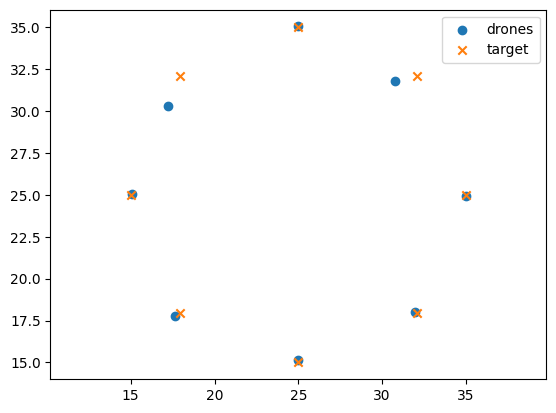

In [11]:
best = gwo.best_pos

plt.scatter(best[:,0], best[:,1], label="drones")
plt.scatter(target_positions[:,0], target_positions[:,1], marker="x", label="target")
plt.legend()
plt.axis("equal")
plt.show()

In [12]:
print(obstacles)

[(18.727005942368123, 47.53571532049581, 5.195981825434215), (29.93292420985183, 7.800932022121826, 3.467983561008608), (2.9041806084099733, 43.308807288746756, 4.8033450352296265), (35.40362888980228, 1.0292247147901223, 5.909729556485983), (41.622132040021086, 10.616955533913808, 3.5454749016213016), (9.17022549267169, 15.212112147976885, 4.574269294896713)]
